# Exploratory Analysis

In [183]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [184]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from olist.data import Olist
data = Olist().get_data()

import utils.UVA as UVA
import utils.MVA as MVA

In [8]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

### 1 - Run an exploratory analysis with [pandas profiling](https://github.com/pandas-profiling/pandas-profiling)

In [40]:
#! pip install pandas-profiling

In [41]:
# create a new "/reports" folder 
!mkdir -p data/reports

In [42]:
import pandas_profiling
datasets_to_profile = ['orders', 'products', 'sellers',
                  'customers', 'order_reviews',
                  'order_items']

In [43]:
#for d in datasets_to_profile:
#    print('exporting: '+d)
#    profile = data[d].profile_report(title='Report for '+d)
#    profile.to_file(output_file="data/reports/"+d+'.html');

### 2 - Create a matching table

Looking at our schema, it would be best to create a central `matching_table` that will join the most important foreign keys together, for later use

❓Create the `matching_table`, a DataFrame with the following columns (below).  
Use outer joins to make sure you don't lose any information at this stage.

In [44]:
columns_matching_table = [
    "order_id",
    "review_id",
    "customer_id",
    "product_id",
    "seller_id",
]

In [45]:
#### Select only the columns of interest in the various dataframes of interest, before proceeding to any merge
orders = data['orders'][['customer_id', 'order_id']]
reviews = data['order_reviews'][['order_id', 'review_id', 'review_score']]
items = data['order_items'][['order_id', 'product_id','seller_id', 'price']]

customers = data['customers'][['customer_id', 'customer_unique_id']]
products = data['products']

In [46]:
# Inspect the cardinality of each DataFrame using pd.DataFrame.shape and pd.Series.nunique()
print('orders:', orders.shape, orders.customer_id.nunique(), 'unique customer_ids, and', orders.order_id.nunique(), 'unique order_ids')
print('review: ', reviews.shape, reviews.order_id.nunique(), 'unique order_ids and', reviews.review_id.nunique(), 'unique reviews' )
print('items: ', items.shape, items.order_id.nunique(), 'unique order_ids,', items.product_id.nunique(), 
      'unique product_ids, and', items.seller_id.nunique(), 'unique seller_ids')

orders: (99441, 2) 99441 unique customer_ids, and 99441 unique order_ids
review:  (99224, 3) 98673 unique order_ids and 98410 unique reviews
items:  (112650, 4) 98666 unique order_ids, 32951 unique product_ids, and 3095 unique seller_ids


In [47]:
# Carefully merge DataFrames
matching_table = orders.merge(reviews, on='order_id', how='left').merge(items, on='order_id', how='left')
matching_table

,customer_id,order_id,review_id,review_score,product_id,seller_id,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,8d5266042046a06655c8db133d120ba5,4.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,e73b67b67587f7644d5bd1a52deb1b01,5.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,359d03e676b3c069f62cadba8dd3f6e8,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,e50934924e227544ba8246aeb3770dd4,5.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90
...,...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,29bb71b2760d0f876dfa178a76bc4734,4.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,371579771219f6db2d830d50805977bb,5.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,8ab6855b9fe9b812cd03a480a25058a1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,8ab6855b9fe9b812cd03a480a25058a1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99


In [48]:
matching_table = orders\
        .merge(customers, on='customer_id', how='outer')\
        .merge(reviews, on="order_id", how="outer")\
        .merge(items, on="order_id", how="outer")
matching_table

,customer_id,order_id,customer_unique_id,review_id,review_score,product_id,seller_id,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,4.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,4.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,5.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,5.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90
...,...,...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,4.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,5.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99


In [49]:
# test get matching table
matching_table_import = Olist().get_matching_table()
matching_table_import

,customer_id,order_id,customer_unique_id,review_id,product_id,seller_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8
...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48


In [50]:
# Inspect the cardinality and `nunique` of the final DataFrame. It should match (114100, 5)
print(matching_table.shape)
print('unique values: ')
print(matching_table.nunique())

(114092, 8)
unique values: 
customer_id           99441
order_id              99441
customer_unique_id    96096
review_id             98410
review_score              5
product_id            32951
seller_id              3095
price                  5968
dtype: int64


In [51]:
# check n# orders per customer

In [52]:
#orders = data['orders'][['customer_id', 'order_id']]
#customers = data['customers'][['customer_id', 'customer_unique_id']]

In [53]:
match_orders = orders.merge(customers, on='customer_id', how='left')

In [54]:
match_orders

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...
99436,39bd1228ee8140590ac3aca26f2dfe00,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a
99437,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660
99438,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30
99439,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c


In [55]:
orders_count = match_orders \
                .groupby('customer_unique_id')['order_id'] \
                .nunique().reset_index(name='orders_count')

In [56]:
orders_count['count_category'] = np.where(orders_count['orders_count'] == 1, '1', '2+')

In [57]:
orders_count.sort_values(by='orders_count', ascending=False)

,customer_unique_id,orders_count,count_category
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17,2+
23472,3e43e6105506432c953e165fb2acf44c,9,2+
37797,6469f99c1f9dfae7733b25662e7f1782,7,2+
76082,ca77025e7201e3b30c44b472ff346268,7,2+
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,2+
...,...,...,...
32508,5657dfebff5868c4dc7e8355fea865c4,1,1
32507,5657596addb4d7b07b32cd330614bdf8,1,1
32506,5656eb169546146caeab56c3ffc3d268,1,1
32505,5656a8fabc8629ff96b2bc14f8c09a27,1,1


In [58]:
orders_info = pd.concat([orders_count['orders_count'].value_counts(normalize=True),
                        orders_count['orders_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count customers'))
orders_info.index.name = 'orders per customer'
orders_info

,percent,count customers
orders per customer,,
1,0.968812,93099
2,0.028565,2745
3,0.002112,203
4,0.000312,30
5,0.000083,8
6,0.000062,6
7,0.000031,3
9,0.000010,1
17,0.000010,1


In [59]:
orders_info_cum = pd.concat([orders_count['count_category'].value_counts(normalize=True),
                        orders_count['count_category'].value_counts()], 
                        axis=1,
                        keys=('perc','count'))
orders_info_cum.index.name = 'orders per customer'


=> ~3.12 % of the total of customers (2997 total) has made more than 1 order.

In [60]:
## selecting / merging data for clustering


In [61]:
match_orders = match_orders.merge(orders_count, on='customer_unique_id', how='left')

In [62]:
match_orders

,customer_id,order_id,customer_unique_id,orders_count,count_category
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2,2+
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,1,1
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,1,1
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,1,1
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,1,1
...,...,...,...,...,...
99436,39bd1228ee8140590ac3aca26f2dfe00,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,1,1
99437,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,1,1
99438,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,1,1
99439,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,1,1


In [63]:
## picking orders from customers_unique_id having made more than 2 orders 
match_orders_2p = match_orders[['customer_id','order_id', 'customer_unique_id']].loc[match_orders['orders_count'] > 1]
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [64]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [65]:
##  adding orders categories and reviews info

In [66]:
reviews

,order_id,review_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,7bc2406110b926393aa56f80a40eba40,4
1,a548910a1c6147796b98fdf73dbeba33,80e641a11e56f04c1ad469d5645fdfde,5
2,f9e4b658b201a9f2ecdecbb34bed034b,228ce5500dc1d8e020d8d1322874b6f0,5
3,658677c97b385a9be170737859d3511b,e64fb393e7b32834bb789ff8bb30750e,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,f7c4243c7fe1938f181bec41a392bdeb,5
...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,574ed12dd733e5fa530cfd4bbf39d7c9,5
99220,22ec9f0669f784db00fa86d035cf8602,f3897127253a9592a73be9bdfdf4ed7a,5
99221,55d4004744368f5571d1f590031933e4,b3de70c89b1510c4cd3d0649fd302472,5
99222,7725825d039fc1f0ceb7635e3f7d9206,1adeb9d84d72fe4e337617733eb85149,4


In [67]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [68]:
m_df = match_orders_2p \
    .merge(items[['order_id', 'product_id', 'price']], on='order_id', how='left') \
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left') \
    .merge(reviews, on='order_id', how='left')

In [69]:
m_df

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name,review_id,review_score
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,a54f0611adc9ed256b57ede6b6eb5114,4.0
1,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f,009c09f439988bc06a93d6b8186dce73,132.40,perfumaria,5a8608437f4b52bec5cd143f37258b5e,5.0
2,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5,638bbb2a5e4f360b71f332ddfebfd672,1299.00,construcao_ferramentas_construcao,NaN,NaN
3,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259,c50ca07e9e4db9ea5011f06802c0aea0,14.49,beleza_saude,5853e27c64b89e222c5e4edf78bec3d4,1.0
4,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514,ba4bfbf74dbe7ab37e263b9326da0523,36.90,esporte_lazer,bcab37e37778893d858b3d159849a56d,4.0
...,...,...,...,...,...,...,...,...
8240,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b,f5e585e188891ed071253bacfad60820,194.80,informatica_acessorios,d3006c9fd3bef31b68bd680fe4098202,5.0
8241,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1,d220fdef3dfe133c5a725ee59ce99595,349.90,automotivo,dd378bada585d0bd633bf39fc9574548,5.0
8242,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,NaN,047fd109ced39e02296f6aeb74f6a6f1,4.0
8243,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc,9e10ae46a3021a02f1692448ef9fa1db,37.90,beleza_saude,47697b20bcd3995f870e284fad248ac8,4.0


In [70]:
# more rows => more items/products total than orders total (i.e. orders with multiple items)
# check out orders with multiple items to be sure it will be usable / absence of duplicates (in price for ex)

In [71]:
product_count = m_df \
                .groupby('order_id')['product_id'] \
                .nunique().reset_index(name='prod_count')
product_count.sort_values(by='prod_count', ascending=False)

,order_id,prod_count
5686,e43f88863d1cc9cff18d753d439d42e8,6
2248,5a3b1c29a49756e75f1ef513383c0c12,6
324,0c57cbfd927d9e62af8beee6d48920b7,5
5075,cc2999bc678cab0949b90c4759d7a284,4
3116,7e3fefb35b0b1d765a343618ca5d454c,4
...,...,...
4579,b90cc9e10252911c2092a1e49794aa13,0
5363,d69fcef5a5fe3a3db60ea65c6ee499cc,0
3038,7a9d4c7f9b068337875b95465330f2fc,0
6148,f81e71dd7c044a9ee7c1d6e37d68d64f,0


In [72]:
product_info = pd.concat([product_count['prod_count'].value_counts(normalize=True),
                        product_count['prod_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count orders'))
product_info.index.name = 'products per order'
product_info

,percent,count orders
products per order,,
1,0.925891,5872
2,0.047304,300
0,0.016872,107
3,0.008199,52
4,0.001261,8
6,0.000315,2
5,0.000158,1


In [73]:
# checking order 5a3b1c29a49756e75f1ef513383c0c12

#m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

# handles duplicates from matching_table (reviews...)
m_df[['product_id', 'price', 'product_category_name']]\
.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']\
.drop_duplicates()

,product_id,price,product_category_name
1415,99444c1e11fc38755dae86f5c67d3d1a,49.99,cama_mesa_banho
1417,17d8b8e9c21ec0fc5b33724e32fe422e,58.90,cama_mesa_banho
1419,399f54c06661d06ca45c6e24ed238e0e,61.90,cama_mesa_banho
1421,6a0713a63e990052795623e76cc2995e,72.90,cama_mesa_banho
1427,d25bbb182b51d1594fe3b54a27ae143e,69.90,cama_mesa_banho
1429,e95fb3a80ca294f39de925b6428f3a32,78.90,cama_mesa_banho


In [74]:
# check products
check_prod = m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5347,d25bbb182b51d1594fe3b54a27ae143e,cama_mesa_banho,34.0,308.0,1.0,1900.0,58.0,15.0,46.0
14912,6a0713a63e990052795623e76cc2995e,cama_mesa_banho,31.0,151.0,1.0,900.0,40.0,4.0,30.0
20180,17d8b8e9c21ec0fc5b33724e32fe422e,cama_mesa_banho,26.0,212.0,2.0,1000.0,30.0,4.0,40.0
25905,e95fb3a80ca294f39de925b6428f3a32,cama_mesa_banho,29.0,263.0,1.0,1300.0,33.0,9.0,38.0
29768,99444c1e11fc38755dae86f5c67d3d1a,cama_mesa_banho,40.0,162.0,1.0,900.0,33.0,9.0,38.0
30087,399f54c06661d06ca45c6e24ed238e0e,cama_mesa_banho,34.0,216.0,2.0,1100.0,33.0,9.0,38.0


In [75]:
items.loc[items['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

,order_id,product_id,seller_id,price
39679,5a3b1c29a49756e75f1ef513383c0c12,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,49.99
39680,5a3b1c29a49756e75f1ef513383c0c12,17d8b8e9c21ec0fc5b33724e32fe422e,d2374cbcbb3ca4ab1086534108cc3ab7,58.90
39681,5a3b1c29a49756e75f1ef513383c0c12,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,61.90
39682,5a3b1c29a49756e75f1ef513383c0c12,6a0713a63e990052795623e76cc2995e,d2374cbcbb3ca4ab1086534108cc3ab7,72.90
39683,5a3b1c29a49756e75f1ef513383c0c12,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,49.99
39684,5a3b1c29a49756e75f1ef513383c0c12,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,61.90
39685,5a3b1c29a49756e75f1ef513383c0c12,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,69.90
39686,5a3b1c29a49756e75f1ef513383c0c12,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,78.90
39687,5a3b1c29a49756e75f1ef513383c0c12,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,78.90
39688,5a3b1c29a49756e75f1ef513383c0c12,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,69.90


In [76]:
# checking order e43f88863d1cc9cff18d753d439d42e8
m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name,review_id,review_score
4291,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,9036be77e0a74cca6eeef0740649b97b,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0
4292,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,238314b88e4b8ffa496db6b1a201d897,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0
4293,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,28447390cfd2a411fcb8c008b6163da2,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0
4294,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,2e0b9273624db778d82fd3b18becec24,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0
4295,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,8fa5bb1e4de7a63ee554487c2f2ee076,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0
4296,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,b65214d387c754bb0f858a4a5a0f41ad,69.99,brinquedos,ced64d7d56565e0385d0953d0dc1e4c7,5.0


In [77]:
# check products
check_prod = m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1102,28447390cfd2a411fcb8c008b6163da2,brinquedos,57.0,696.0,4.0,405.0,21.0,7.0,16.0
14154,8fa5bb1e4de7a63ee554487c2f2ee076,brinquedos,58.0,696.0,4.0,325.0,21.0,7.0,16.0
19331,2e0b9273624db778d82fd3b18becec24,brinquedos,57.0,707.0,4.0,345.0,19.0,16.0,18.0
23282,9036be77e0a74cca6eeef0740649b97b,brinquedos,57.0,697.0,3.0,405.0,21.0,7.0,15.0
24483,b65214d387c754bb0f858a4a5a0f41ad,brinquedos,57.0,696.0,4.0,325.0,21.0,7.0,16.0
31683,238314b88e4b8ffa496db6b1a201d897,brinquedos,56.0,696.0,4.0,300.0,21.0,7.0,16.0


In [78]:
items.loc[items['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,order_id,product_id,seller_id,price
100670,e43f88863d1cc9cff18d753d439d42e8,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,69.99
100671,e43f88863d1cc9cff18d753d439d42e8,238314b88e4b8ffa496db6b1a201d897,de23c3b98a88888289c6f5cc1209054a,69.99
100672,e43f88863d1cc9cff18d753d439d42e8,28447390cfd2a411fcb8c008b6163da2,de23c3b98a88888289c6f5cc1209054a,69.99
100673,e43f88863d1cc9cff18d753d439d42e8,2e0b9273624db778d82fd3b18becec24,de23c3b98a88888289c6f5cc1209054a,69.99
100674,e43f88863d1cc9cff18d753d439d42e8,8fa5bb1e4de7a63ee554487c2f2ee076,de23c3b98a88888289c6f5cc1209054a,69.99
100675,e43f88863d1cc9cff18d753d439d42e8,b65214d387c754bb0f858a4a5a0f41ad,de23c3b98a88888289c6f5cc1209054a,69.99


In [79]:
# => may have to handle the "duplicate" prices not matching reality (price of the whole order for singular products)

In [80]:
## conseils vidéo introductive projet : https://www.youtube.com/watch?v=BI4UFzIYBG8
# méthodologie, itérations.
# commencer par features simples, ex :
#   RFM :
#    - Récence : nb de jours depuis dernier achat,
#    - Fréquence : nb de fois que la personne a acheté,
#    - Montant :montant total des achats
# 
# => lier tables, agréger features (groupby, agg)
# 
# => faire bivariée sur le dataset créé
#
# une fois dataset obtenu, débuter modélisation
# - bien analyser données
#   - faire PCA
#   - projeter individus
#   - faire cercle de correlations
#
#   (Score de silhouette)
#
# - modélisation
#   - CAAH
#   - KMEANS (boucler sur plusieurs clusters, radar chart)
#   - dbscan
#   - déterminer nb clusters
#   - regarder/analyser clusters : bien comprendre les distinctions
#
# - repasser sur données
#   - ajouter quelques features sur dataset : reviewscore moyen, différence date d'achat/livraison, retard/delta livraison
#   - 
#   - 
#
# - débuter travail maintenance
#   - étape importante
#   - dder mentor


# Dataset RFM

## Préparation

In [81]:
data['orders']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [82]:
ord_time = data['orders'][['order_id','customer_id', 'order_purchase_timestamp']]
ord_time = ord_time.merge(customers, on='customer_id', how='left')\
[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27


In [83]:
ord_time['order_purchase_timestamp'] = pd.to_datetime(ord_time['order_purchase_timestamp']).dt.date

In [84]:
ord_time['order_purchase_timestamp'].isnull().values.any()

False

In [85]:
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08


In [86]:
orders_price = items.groupby(['order_id']).agg('sum')
orders_price.head()

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [87]:
# rename / reorganize dataset
ord_df = ord_time.merge(orders_price, on='order_id', how='outer')
ord_df.rename({'price':'total_revenue', 'order_purchase_timestamp': 'purchase_date'}, axis='columns', inplace=True)
ord_df = ord_df[['order_id', 'customer_unique_id', 'total_revenue', 'purchase_date']]
ord_df

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,2018-01-08


In [88]:
# Recency

=> To define 'Recency' we have to take into account the limit of the current dataframe, more than a min/max date, a simple analysis/display of the distribution of orders over dates would help (can cover some errors/outliers to get the general picture).

In [89]:
# check min / max dates and overall dates distribution of orders
# convert timestamp to date

In [90]:
ord_df.dtypes

order_id               object
customer_unique_id     object
total_revenue         float64
purchase_date          object
dtype: object

In [91]:
min_date = ord_df['purchase_date'].min(axis=0)
max_date = ord_df['purchase_date'].max(axis=0)
print(min_date)
print(max_date)

2016-09-04
2018-10-17


In [92]:
ord_time_dist = ord_df['purchase_date'].value_counts().sort_index()
ord_time_dist

2016-09-04    1
2016-09-05    1
2016-09-13    1
2016-09-15    1
2016-10-02    1
             ..
2018-09-29    1
2018-10-01    1
2018-10-03    1
2018-10-16    1
2018-10-17    1
Name: purchase_date, Length: 634, dtype: int64

In [93]:
#ord_time_dist.plot()

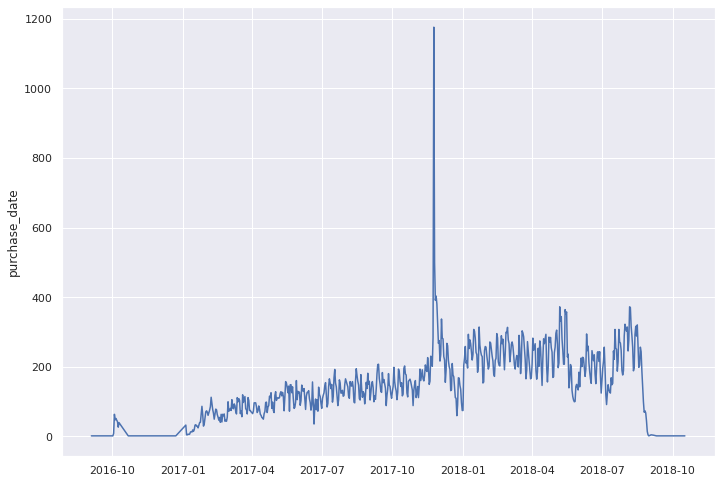

In [94]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
g = sns.lineplot(data=ord_time_dist)

In [95]:
max_date

datetime.date(2018, 10, 17)

In [96]:
ord_df

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,2018-01-08


In [97]:
# https://practicaldatascience.co.uk/data-science/how-to-assign-rfm-scores-with-quantile-based-discretization
# => Recency is a measure of the number of days since the customer last placed an order. 

In [98]:
df_customers = pd.DataFrame(ord_df['customer_unique_id'].unique())
df_customers.columns = ['customer_unique_id']
df_customers.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
1,af07308b275d755c9edb36a90c618231
2,3a653a41f6f9fc3d2a113cf8398680e8
3,7c142cf63193a1473d2e66489a9ae977
4,72632f0f9dd73dfee390c9b22eb56dd6


In [99]:
df_recency = ord_df.groupby('customer_unique_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_unique_id'
                      ,'recency_date'
                     ]
df_customers = df_customers.merge(df_recency, on='customer_unique_id')
df_customers['recency'] = round((pd.to_datetime('2018-10-17') - pd.to_datetime(df_customers['recency_date']))\
                                / np.timedelta64(1, 'D') ).astype(int)

In [100]:
### Frequency

# Order frequency is simply the number of orders each customer has placed. 

In [101]:
df_frequency = ord_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id','frequency']
df_customers = df_customers.merge(df_frequency, on='customer_unique_id')

In [102]:
### Monetary value

# The monetary value column is the sum() of the total_revenue column for each customer. 

In [103]:
df_monetary = ord_df.groupby('customer_unique_id')['total_revenue'].sum().reset_index()
df_monetary.columns = ['customer_unique_id','monetary']
df_customers = df_customers.merge(df_monetary, on='customer_unique_id')

In [104]:
df_customers.drop(['recency_date'], axis=1, inplace=True)

In [105]:
df_customers

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
...,...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
96092,da62f9e57a76d978d02ab5362c509660,253,1,174.90
96093,737520a9aad80b3fbbdad19b66b37b30,416,1,205.99
96094,5097a5312c8b157bb7be58ae360ef43c,282,1,359.98


## Analyse uni-variée

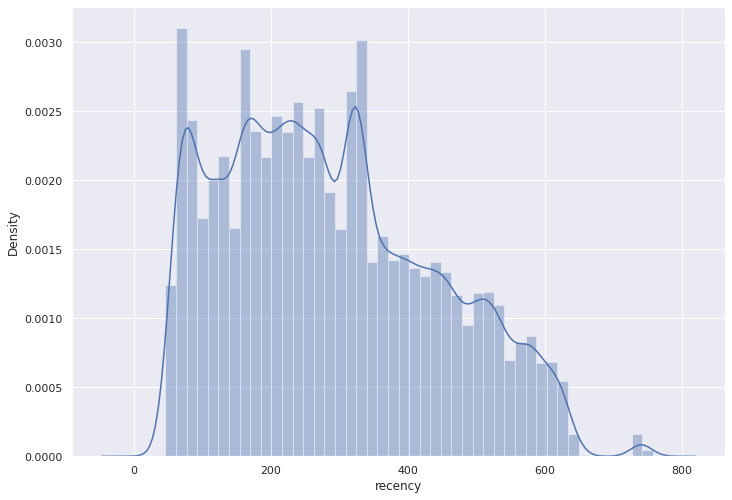

In [106]:
# statistical distribution
ax = sns.distplot(df_customers['recency'])

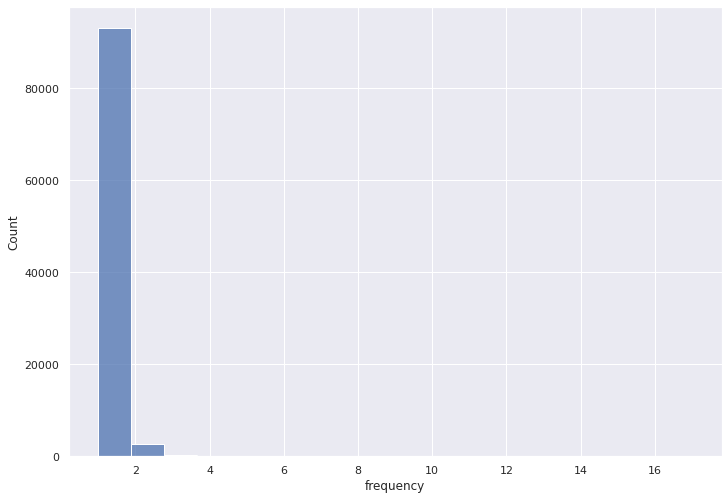

In [107]:
ax = sns.histplot(df_customers['frequency'])

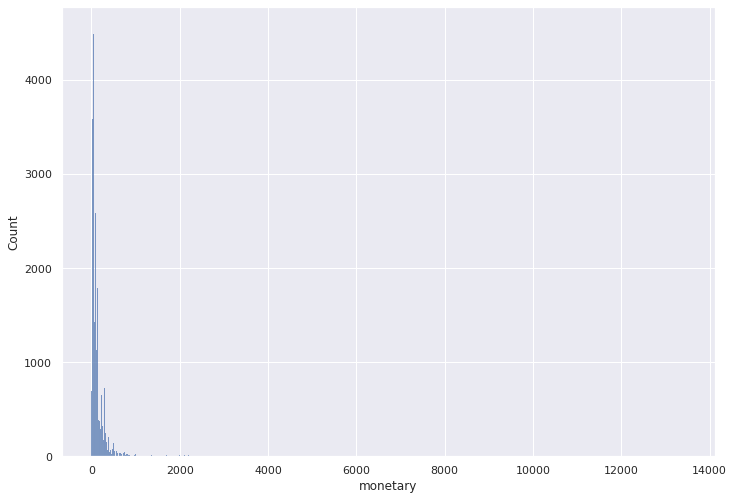

In [108]:
ax = sns.histplot(df_customers['monetary'])

In [111]:
df_customers.dtypes

customer_unique_id     object
recency                 int64
frequency               int64
monetary              float64
dtype: object

In [181]:
num_cols = df_customers.select_dtypes(include=['int64','float64','Int64'])[:]
num_cols.dtypes

recency        int64
frequency      int64
monetary     float64
dtype: object

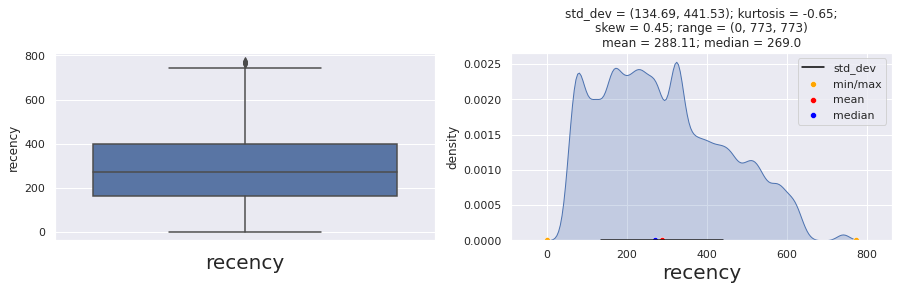

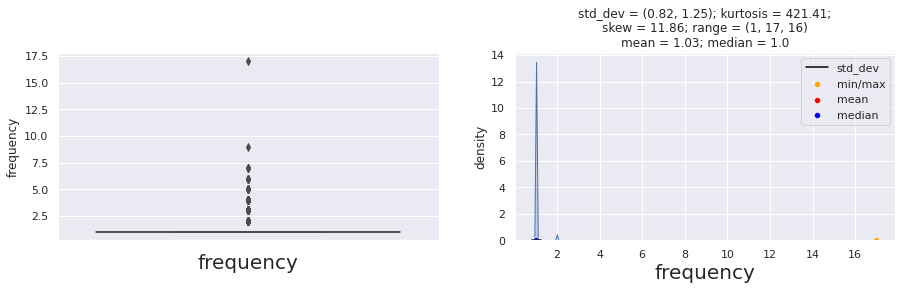

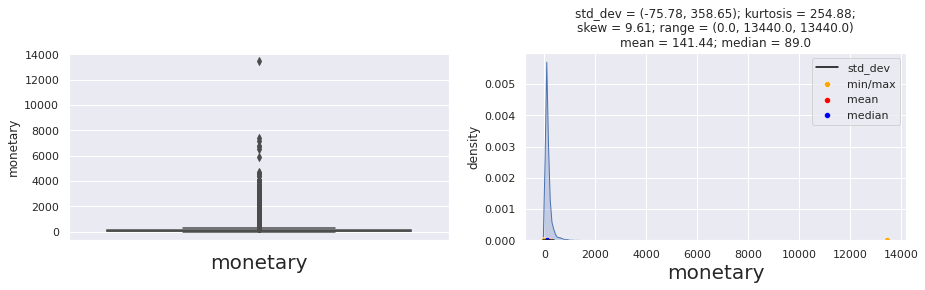

In [182]:
UVA.num_plus(df_customers, num_cols)

## Analyse bi-variée

In [195]:
df_customers.dtypes

customer_unique_id     object
recency                 int64
frequency               int64
monetary              float64
dtype: object

In [230]:
import utils.UVA as UVA
import utils.MVA as MVA

<Figure size 1875x1240.5 with 0 Axes>

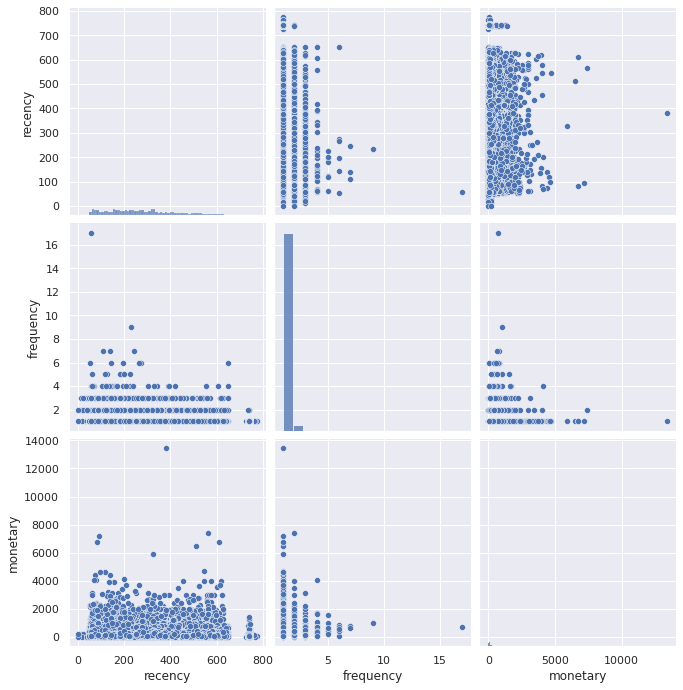

In [231]:
MVA.pairplot(df_customers)

In [237]:
num_log.dtypes

recency        int64
frequency      int64
monetary     float64
dtype: object

<Figure size 1875x1240.5 with 0 Axes>

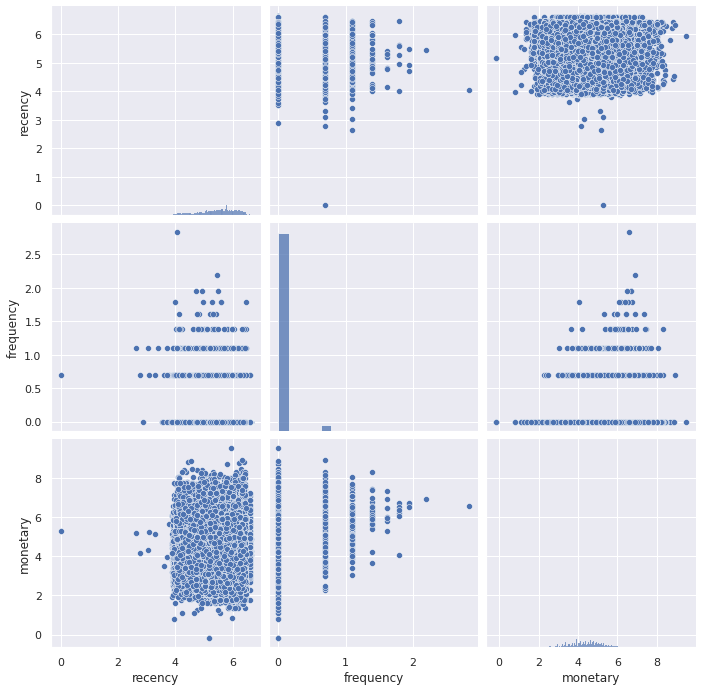

In [239]:
#taking log of every value to negate outliers
num_log = df_customers.select_dtypes(include=['int64','float64','Int64'])[:]

for column in num_log:
  mini=1
  if num_log[column].min()<0:
    mini =  abs(numerical[column].min()) + 1
  
  num_log[column] = [i+mini for i in numerical[column]]
  num_log[column] = numerical[column].map(lambda x : np.log(x))

pairplot(num_log)

## Multi-variée : Heatmap / matrice corrélation

In [198]:
# calculating correlation
num_cols = df_customers.select_dtypes(include=['int64','float64','Int64'])[:]

correlation = num_cols.dropna().corr()
correlation

,recency,frequency,monetary
recency,1.000000,-0.024869,-0.001873
frequency,-0.024869,1.000000,0.106440
monetary,-0.001873,0.106440,1.000000


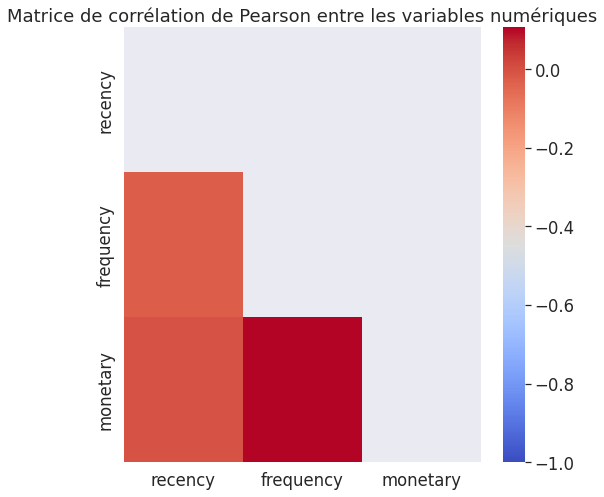

In [178]:
MVA.heatmap_num(df_customers, annot=True) ## annot true contrast

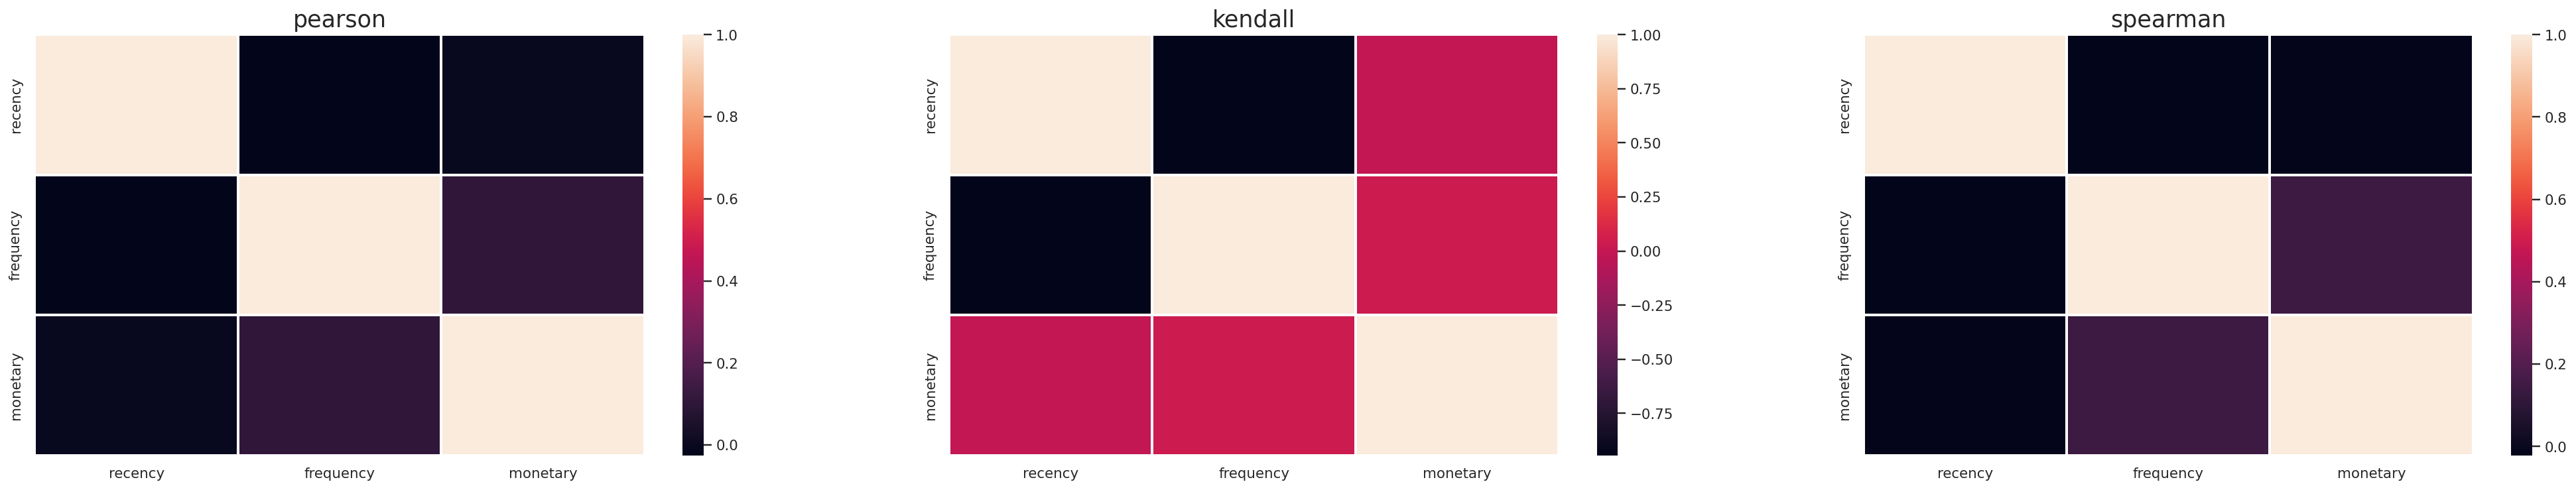

In [189]:
MVA.all_heatmaps(df_customers)

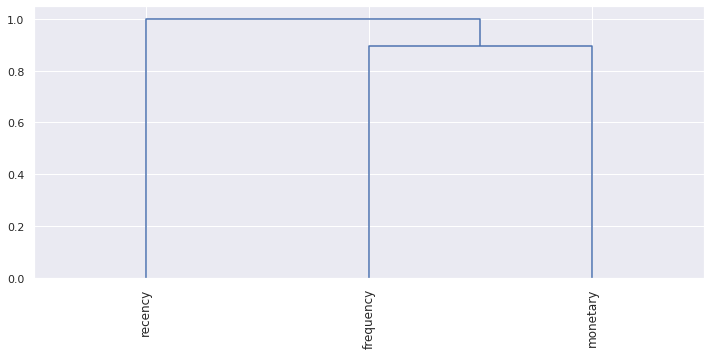

In [232]:
MVA.dendrogram(df_customers)

In [115]:
## method building : error check/catch : only process if elements are numerical values

In [ ]:
## todo : clustering sur RFM : kmeans / dbscan

In [ ]:
## essayer d'afficher avec 